In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### NEW ####
import statsmodels.api as sm

- https://seeing-theory.brown.edu/regression-analysis/index.html#section1
- https://en.wikipedia.org/wiki/Anscombe%27s_quartet

**Chat**, why is Anscombe's quartet important?

In [ ]:
df = sns.load_dataset('anscombe')
df.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [ ]:
df["dataset"].unique()

array(['I', 'II', 'III', 'IV'], dtype=object)

In [ ]:
df.groupby(by="dataset").describe()

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

In [ ]:
covs = df.groupby('dataset')[['x', 'y']].apply(lambda g: g.cov().iloc[0, 1])

covs_df = covs.reset_index(name='cov_xy')

print(covs_df)

  dataset  cov_xy
0       I   5.501
1      II   5.500
2     III   5.497
3      IV   5.499


**Chat**,
1. If two 2d data sets have the same means, variances and covariances, will they have the same regression line?
2. Show me the normal equations in matrix form.

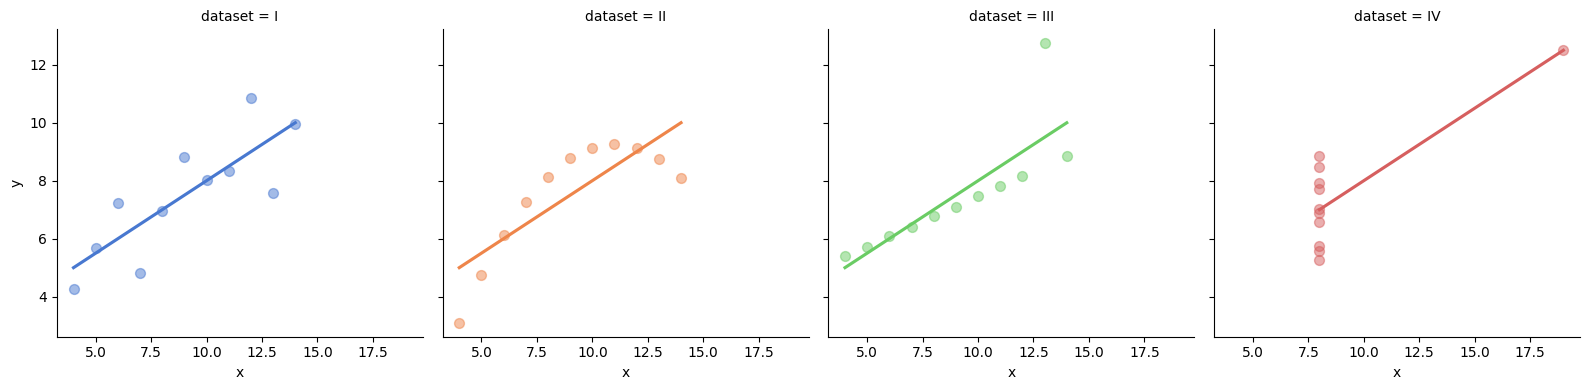

In [ ]:
sns.lmplot(
    data=df, x="x", y="y", col="dataset", hue="dataset",
    col_wrap=4, palette="muted", ci=None,
    scatter_kws={"s": 50, "alpha": 0.5},height=4
)

In [ ]:
ds = "I"
df1 = df[df["dataset"] == ds]
df1.head()


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


#Ordinary Least Squares


https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.html

**Chat**,
1. What are the assumptions of OLS? What happens if they’re violated?
2. Express the assumptions succinctly as a constraint on the joint distribution of the errors.
3. Why is polynomial regression a special case of linear regression?

In [ ]:
design = np.column_stack((df1["x"], np.ones(len(df1))))
design[0:5,:]

array([[10.,  1.],
       [ 8.,  1.],
       [13.,  1.],
       [ 9.,  1.],
       [11.,  1.]])

In [ ]:
results = sm.OLS(df1["y"],design).fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     17.99
Date:                Wed, 06 May 2026   Prob (F-statistic):            0.00217
Time:                        11:37:08   Log-Likelihood:                -16.841
No. Observations:                  11   AIC:                             37.68
Df Residuals:                       9   BIC:                             38.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5001      0.118      4.241      0.0

**Chat**, explain this statmodels OLS output: <Copy & Paste>

**$R^2$:**
  - https://en.wikipedia.org/wiki/Coefficient_of_determination

**F-statistic:**

**Chat**,
1. What's the F-statistic and its probability?
1. What's the omnibus test up there?
2. Wiki says omnibus is a different test, what's up with that? https://en.wikipedia.org/wiki/Omnibus_test#In_multiple_regression
4. What do kurtosis and skew say about a given distribution?
  - How do they relate to tests of normality?
  - Draw two figures to illustrate the different cases for each. Color the differnet curves with RGB. Center the skewed distributions at zero.


**Chat**,
1. What's **AIC, BIC**?
  - https://en.wikipedia.org/wiki/Akaike_information_criterion


**$P>|t|$:** t-test, H0: coeff = 0


In [ ]:
print(results.predict([2, 1]),
      results.params["x1"]*2 + results.params["const"],
sep="\n")

[4.00027273]
4.000272727272727


In [ ]:
results_dict = {}
for ds in df["dataset"].unique():
    print(ds)
    df1 = df[df["dataset"] == ds]
    design = np.column_stack((df1["x"], np.ones(len(df1))))
    results_dict[ds] = sm.OLS(df1["y"],design).fit()
    print(results_dict[ds].summary())

I
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     17.99
Date:                Wed, 06 May 2026   Prob (F-statistic):            0.00217
Time:                        11:37:08   Log-Likelihood:                -16.841
No. Observations:                  11   AIC:                             37.68
Df Residuals:                       9   BIC:                             38.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5001      0.118      4.241      0

#Residual Plots
Assumptions:
- No pattern (independent errors)
- Normally distributed

**Chat**, what should I look for in residual plots?


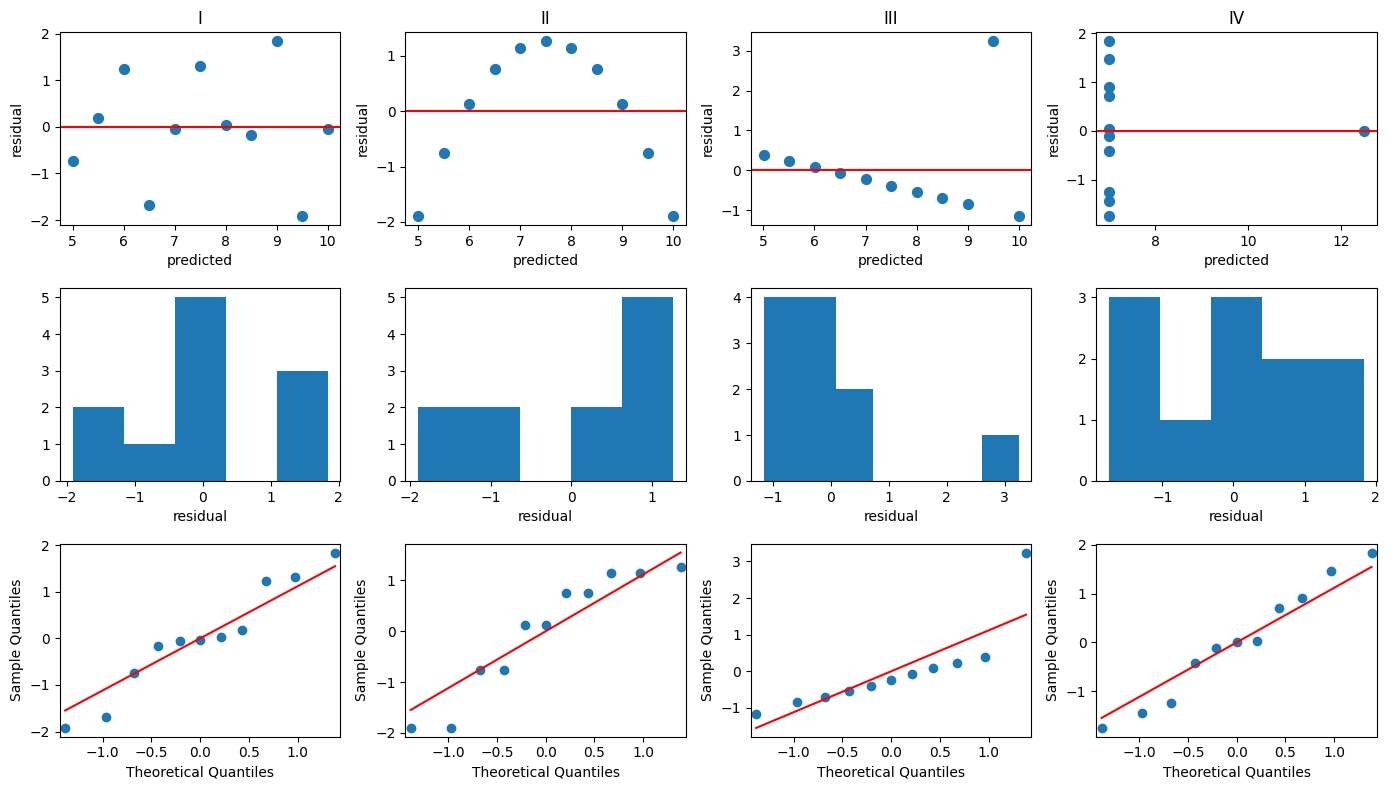

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for i, ds in enumerate(df["dataset"].unique()):
    ax = axes[0,i]
    results = results_dict[ds]
    ax.scatter(results.predict(), results.resid, s=50)
    ax.axhline(0, color="red")
    ax.set_title(ds)
    ax.set_xlabel("predicted")
    ax.set_ylabel("residual")

    #this works better with more data.
    ax = axes[1,i]
    ax.hist(results.resid,bins="auto")
    ax.set_xlabel("residual")

    ax = axes[2,i]
    sm.graphics.qqplot(results.resid, line="s", ax=ax)


    plt.tight_layout()

**Chat**,
1. Analyze these <copy image & paste>.
2. Are the quantiles normalized in     `sm.graphics.qqplot(results.resid,line="s", ax=ax)`?


#Leverage, Influence
  - https://seeing-theory.brown.edu/regression-analysis/index.html#section1


**Chat**,
1. What's leverage in OLS? make sure to mention the hat matrix. Explain intuitively the meaning of its digonal elements.
2. is it always the case that $0\le h_{ii}\le 1$? Why?
3. What's influence in OLS? How do I calculate it? Discuss leverage vs residuals. Which data points should I watch out for?

- https://www.statsmodels.org/stable/examples/notebooks/generated/regression_plots.html
- https://www.statsmodels.org/dev/examples/notebooks/generated/linear_regression_diagnostics_plots.html

point size = Influence.

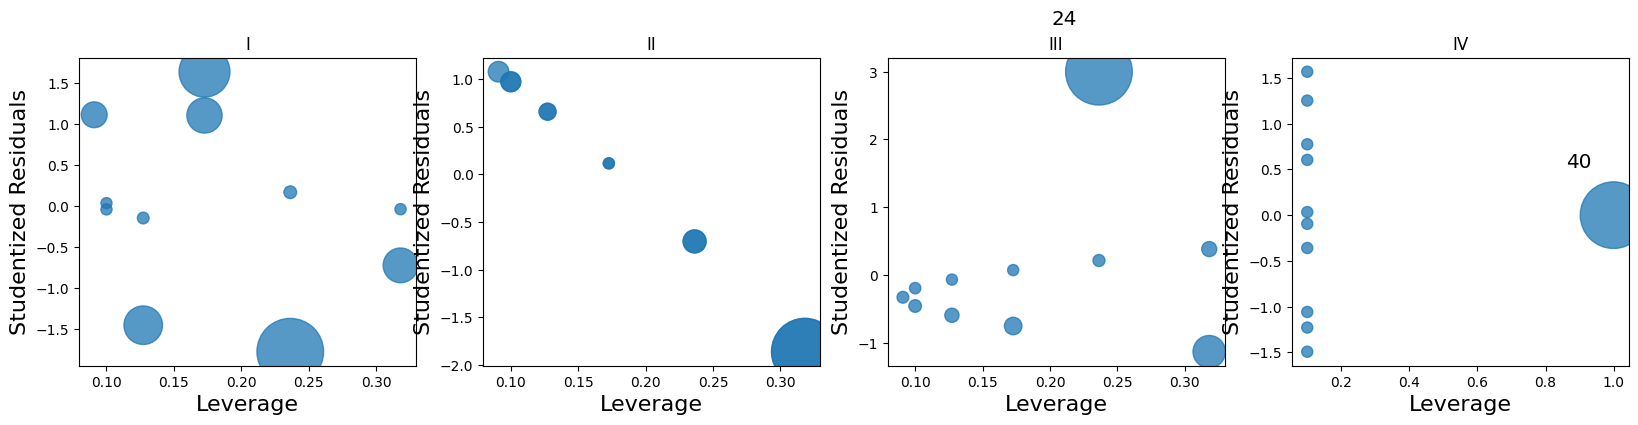

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, ds in enumerate(df["dataset"].unique()):
    ax = axes[i]
    results = results_dict[ds]
    results.get_influence().plot_influence(ax=ax)
    ax.set_title(ds)

**Chat**,
1. Analyze this <copy & paste>
2. What are studentized residuals? What are they useful for?

#Outliers
\#40 in IV is an outlier - drop it and rerun the regression.

In [ ]:
df1 = df[df["dataset"] == "IV"]
print(df1)

   dataset     x      y
33      IV   8.0   6.58
34      IV   8.0   5.76
35      IV   8.0   7.71
36      IV   8.0   8.84
37      IV   8.0   8.47
38      IV   8.0   7.04
39      IV   8.0   5.25
40      IV  19.0  12.50
41      IV   8.0   5.56
42      IV   8.0   7.91
43      IV   8.0   6.89


In [ ]:
df2 = df1.drop([40])
design = np.column_stack((df2["x"], np.ones(len(df2))))
results = sm.OLS(df2["y"],design).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 06 May 2026   Prob (F-statistic):                nan
Time:                        11:38:01   Log-Likelihood:                -15.779
No. Observations:                  10   AIC:                             33.56
Df Residuals:                       9   BIC:                             33.86
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8617      0.048     17.916      0.0

In [ ]:
design = np.column_stack((df2["x"], np.ones(len(df2))))
print(design)

[[8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]
 [8. 1.]]


In [ ]:
sm.graphics.plot_fit(results,0);

**Chat**, what's going on here? <copy & paste image + resluts.summary>

#Feature engineering
II:
- looks like a quadratic.
- residuals show structure.

=> Linear model is inadequate.

**Chat**, Anscombe's quartet set II regression line residuals show structure, what can I do to fit a better model?

In [ ]:
df1 = df[df["dataset"] == "II"]
design = np.column_stack((df1["x"]**2, df1["x"], np.ones(len(df1))))
results = sm.OLS(df1["y"],design).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.378e+06
Date:                Wed, 06 May 2026   Prob (F-statistic):           8.64e-26
Time:                        11:47:32   Log-Likelihood:                 56.471
No. Observations:                  11   AIC:                            -106.9
Df Residuals:                       8   BIC:                            -105.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.1267   5.71e-05  -2219.238      0.0

In [ ]:
design

array([[100.,  10.,   1.],
       [ 64.,   8.,   1.],
       [169.,  13.,   1.],
       [ 81.,   9.,   1.],
       [121.,  11.,   1.],
       [196.,  14.,   1.],
       [ 36.,   6.,   1.],
       [ 16.,   4.,   1.],
       [144.,  12.,   1.],
       [ 49.,   7.,   1.],
       [ 25.,   5.,   1.]])

Text(0, 0.5, 'residual')

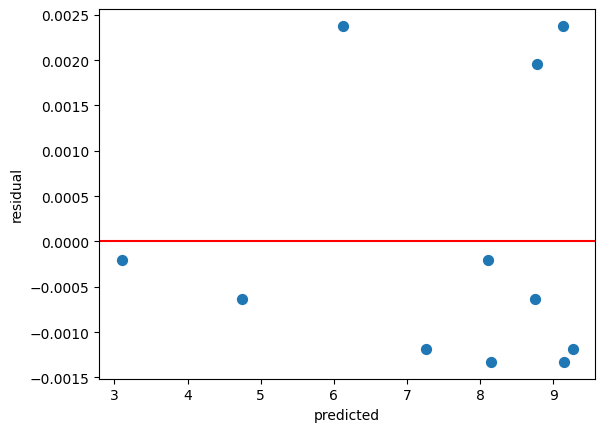

In [ ]:
  plt.scatter(results.predict(), results.resid, s=50)
  plt.axhline(0, color="red")
  plt.xlabel("predicted")
  plt.ylabel("residual")

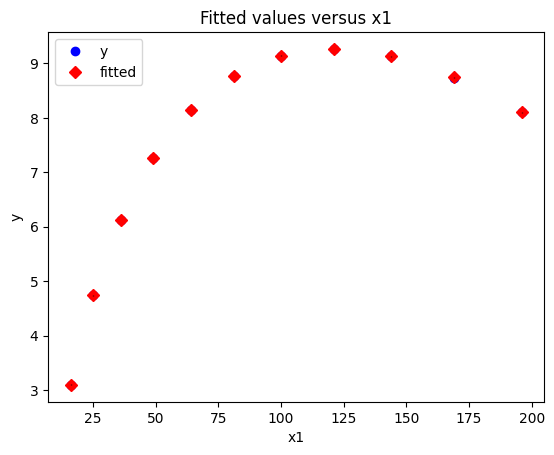

In [ ]:
sm.graphics.plot_fit(results,0);

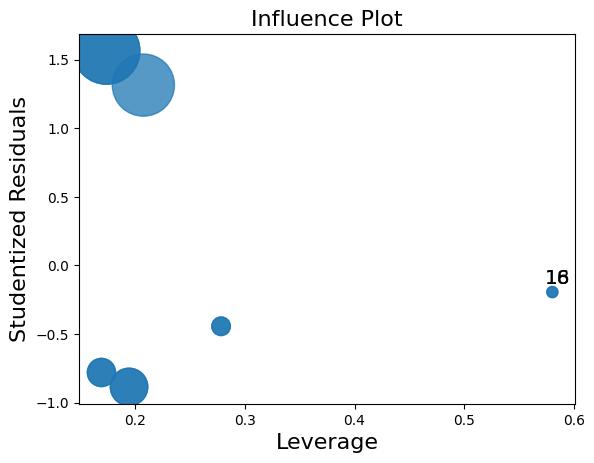

In [ ]:
results.get_influence().plot_influence();

**Chat**, I fit a quadratic to Anscombe's quartet dataset No. 2. Why are the studentized residuals so large even when the fit is almost perfect? Mention the effect of the MSE on the denominator of the studentized residuals.

#Feature engineering - dummy variables
- https://en.wikipedia.org/wiki/Datasaurus_dozen

In [ ]:
!curl -O https://www.openintro.org/data/csv/datasaurus.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 64110  100 64110    0     0   149k      0 --:--:-- --:--:-- --:--:--  149k


**Chat**, what's curl?

In [ ]:
df = pd.read_csv("datasaurus.csv")
# df = pd.read_csv("https://www.openintro.org/data/csv/datasaurus.csv")

df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


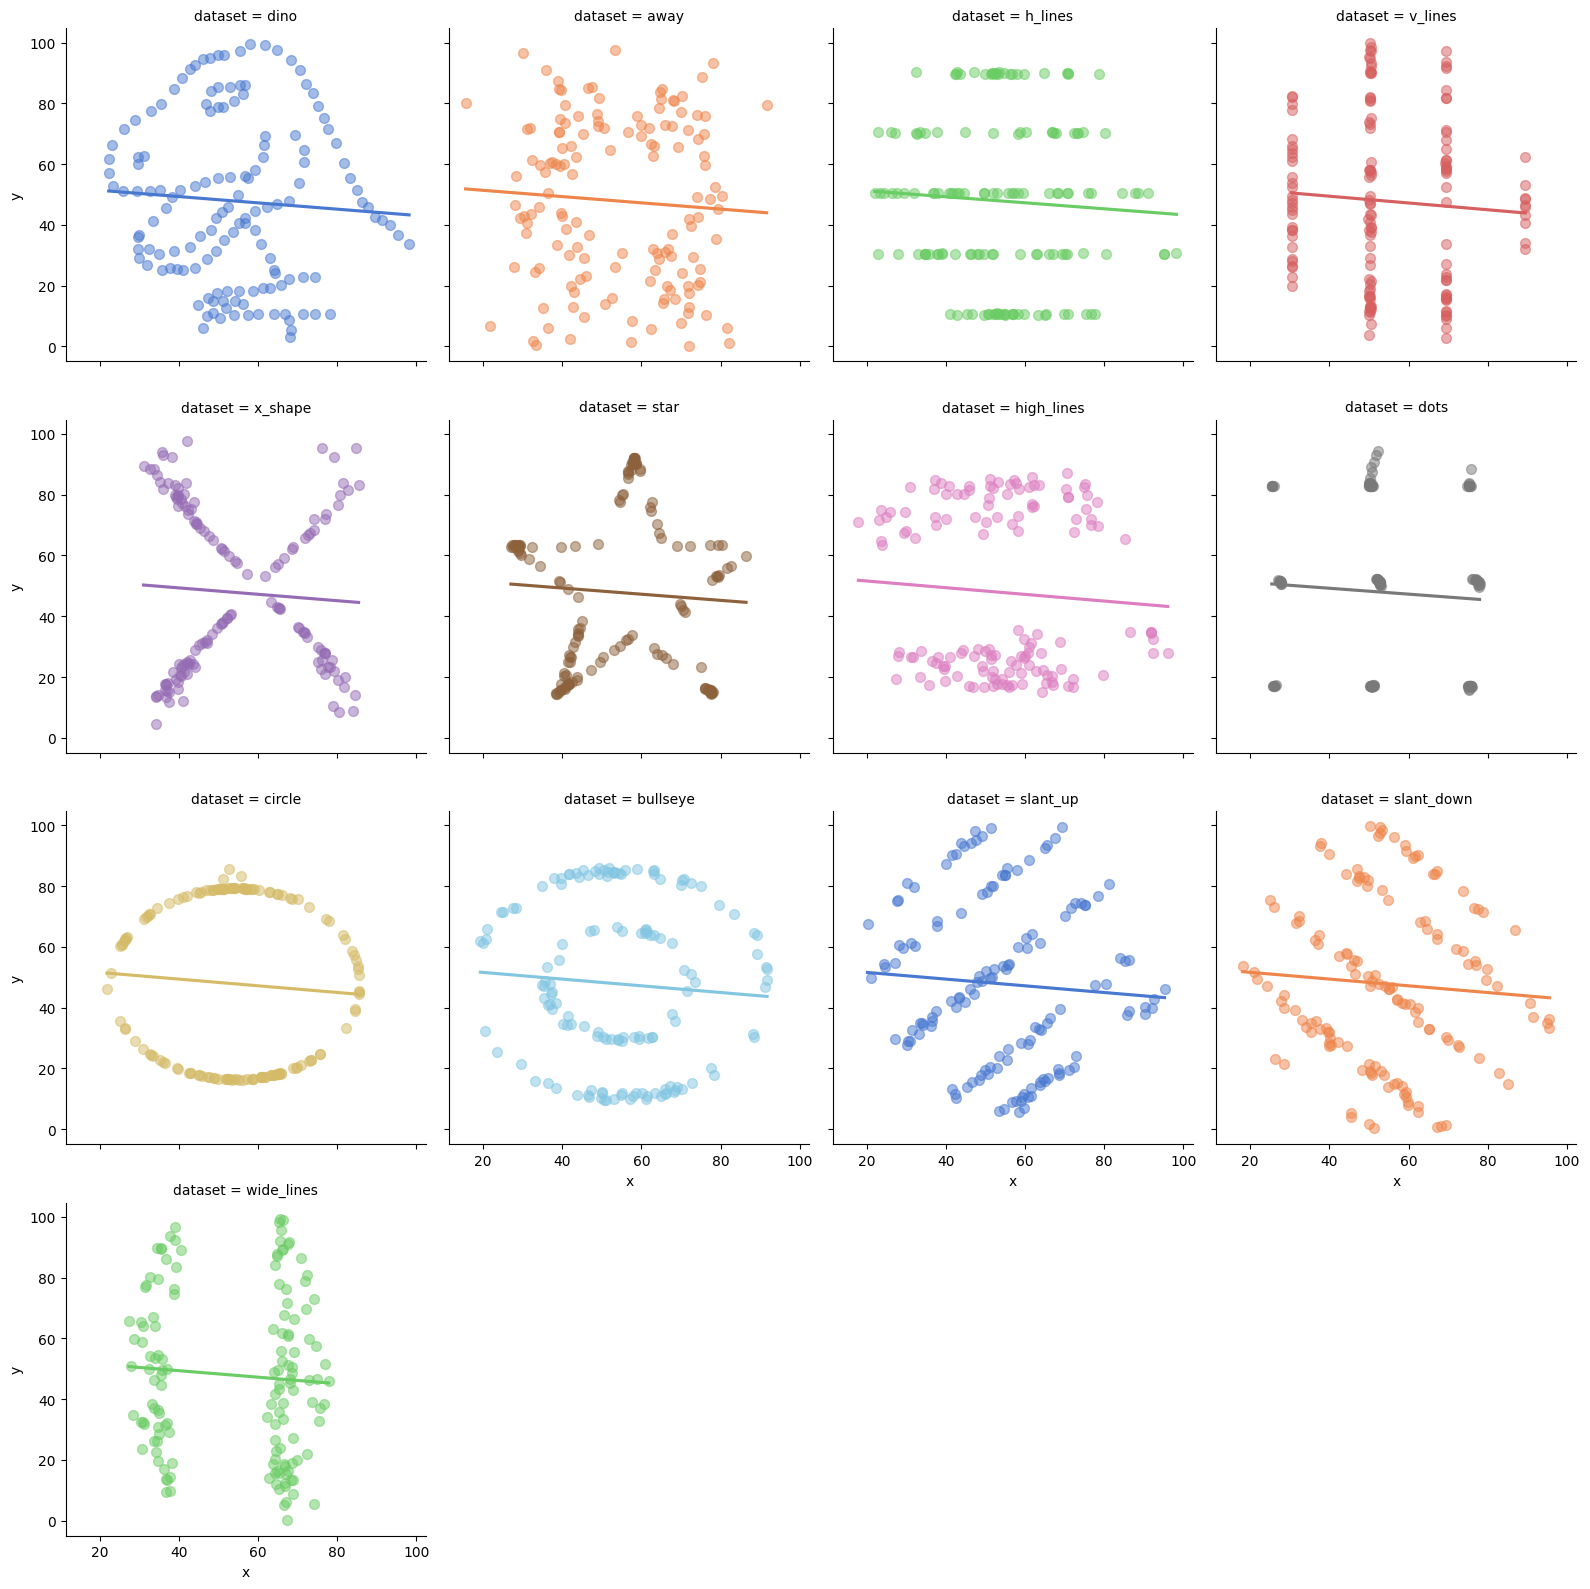

In [ ]:
sns.lmplot(
    data=df, x="x", y="y", col="dataset", hue="dataset",
    col_wrap=4, palette="muted", ci=None,
    scatter_kws={"s": 50, "alpha": 0.5},height=4
)

In [ ]:
df.groupby(by="dataset").describe()

x                                                         \
            count       mean        std        min        25%        50%   
dataset                                                                    
away        142.0  54.266100  16.769825  15.560750  39.724115  53.340296   
bullseye    142.0  54.268730  16.769239  19.288205  41.627968  53.842088   
circle      142.0  54.267320  16.760013  21.863581  43.379116  54.023213   
dino        142.0  54.263273  16.765142  22.307700  44.102600  53.333300   
dots        142.0  54.260303  16.767735  25.443526  50.359707  50.976768   
h_lines     142.0  54.261442  16.765898  22.003709  42.293828  53.069678   
high_lines  142.0  54.268805  16.766704  17.893499  41.535981  54.168689   
slant_down  142.0  54.267849  16.766759  18.109472  42.890931  53.135159   
slant_up    142.0  54.265882  16.768853  20.209778  42.810866  54.261345   
star        142.0  54.267341  16.768959  27.024603  41.034210  56.534732   
v_lines     142.0  54.269927  16.769959  30.449654  49.964506  50.362890   
wide_lines  142.0  54.266916  16.770000  27.439632  35.522449  64.550226   
x_shape     142.0  54.260150  16.769958  31.106867  40.091656  47.136458   

                                      y                                   \
                  75%        max  count       mean        std        min   
dataset                                                                    
away        69.146597  91.639961  142.0  47.834721  26.939743   0.015119   
bullseye    64.798900  91.735539  142.0  47.830823  26.935727   9.691547   
circle      64.972672  85.664761  142.0  47.837717  26.930036  16.326546   
dino        64.743600  98.205100  142.0  47.832253  26.935403   2.948700   
dots        75.197363  77.954435  142.0  47.839829  26.930192  15.771892   
h_lines     66.768274  98.288123  142.0  47.830252  26.939876  10.463915   
high_lines  63.952667  96.080519  142.0  47.835450  26.939998  14.913962   
slant_down  64.469989  95.593416  142.0  47.835896  26.936105   0.303872   
slant_up    64.488010  95.260528  142.0  47.831496  26.938608   5.645777   
star        68.711493  86.435897  142.0  47.839545  26.930275  14.365590   
v_lines     69.504068  89.504851  142.0  47.836988  26.937684   2.734760   
wide_lines  67.453672  77.915874  142.0  47.831602  26.937902   0.217006   
x_shape     71.856923  85.446186  142.0  47.839717  26.930002   4.577661   

                                                        
                  25%        50%        75%        max  
dataset                                                 
away        24.625892  47.535269  71.803148  97.475771  
bullseye    26.244735  47.382937  72.532852  85.876229  
circle      18.349610  51.025022  77.782382  85.578134  
dino        25.288450  46.025600  68.525675  99.487200  
dots        17.107141  51.299291  82.881589  94.249328  
h_lines     30.479911  50.473527  70.349471  90.458936  
high_lines  22.920843  32.499203  75.940022  87.152208  
slant_down  27.840858  46.401314  68.439430  99.644179  
slant_up    24.756248  45.292238  70.855844  99.579591  
star        20.374135  50.110554  63.548584  92.214989  
v_lines     22.752884  47.113616  65.845391  99.694680  
wide_lines  24.346941  46.279331  67.568127  99.283764  
x_shape     23.470809  39.876211  73.609634  97.837615

In [ ]:
df1=df[df["dataset"] == "h_lines"]
df1

,dataset,x,y
284,h_lines,53.366567,90.208030
285,h_lines,52.801979,90.088065
286,h_lines,47.054130,90.458936
287,h_lines,42.448434,89.507700
288,h_lines,42.704036,90.442629
...,...,...,...
421,h_lines,42.224120,30.498037
422,h_lines,87.698464,50.489937
423,h_lines,52.360331,89.704317
424,h_lines,51.406787,89.712139


In [ ]:
design = np.column_stack((df1["x"], np.ones(len(df1))))
results = sm.OLS(df1["y"],design).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.5353
Date:                Wed, 06 May 2026   Prob (F-statistic):              0.466
Time:                        12:21:29   Log-Likelihood:                -668.41
No. Observations:                 142   AIC:                             1341.
Df Residuals:                     140   BIC:                             1347.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0992      0.136     -0.732      0.4

In [ ]:
from sklearn.cluster import DBSCAN
clustering = DBSCAN(eps=15, min_samples=4).fit(df1[["x","y"]])
clustering.labels_

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 1, 1, 2, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 3, 3, 2, 0, 0, 0])

<Axes: xlabel='x', ylabel='y'>

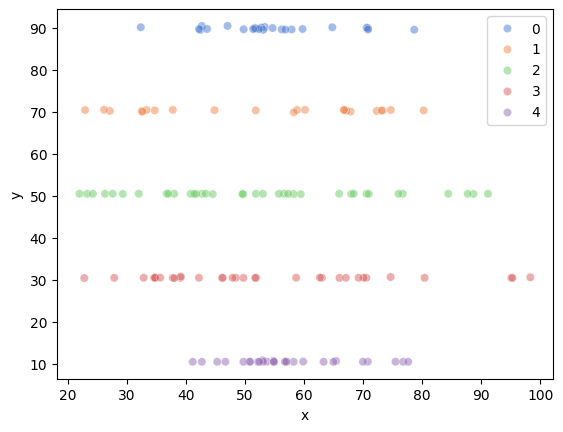

In [ ]:
sns.scatterplot(
    data=df1, x="x", y="y", hue=clustering.labels_, palette="muted", alpha=0.5,
    legend="brief",
)



**Chat**, what’s one-hot encoding? Show me an example. Why is it useful in the context of OLS?

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
enc.fit(clustering.labels_.reshape(-1, 1))
onehotlabels = enc.transform(clustering.labels_.reshape(-1, 1))
one_hot = onehotlabels.toarray()
one_hot[0:10,:]

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [ ]:
design = np.column_stack((df1["x"], np.ones(len(df1)),one_hot))
results = sm.OLS(df1["y"],design).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.021e+06
Date:                Wed, 06 May 2026   Prob (F-statistic):          3.68e-309
Time:                        12:20:10   Log-Likelihood:                 79.189
No. Observations:                 142   AIC:                            -146.4
Df Residuals:                     136   BIC:                            -128.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0004      0.001     -0.516      0.6

In [ ]:
design[0:5,:]

array([[53.36656687,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [52.80197936,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [47.05412988,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [42.44843378,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [42.70403632,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ]])

**Chat**,
1. What's multicollinearity in OLS? Is it always a problem?
1. Explain the dummy variable trap in OLS.

In [ ]:
(one_hot[:,-1] == 1 - one_hot[:,:-1].sum(axis=1)).all()

np.True_

In [ ]:
design = np.column_stack((df1["x"], np.ones(len(df1)),one_hot[:,:-1]))
results = sm.OLS(df1["y"],design).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.021e+06
Date:                Wed, 06 May 2026   Prob (F-statistic):          3.68e-309
Time:                        11:47:48   Log-Likelihood:                 79.189
No. Observations:                 142   AIC:                            -146.4
Df Residuals:                     136   BIC:                            -128.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0004      0.001     -0.516      0.6

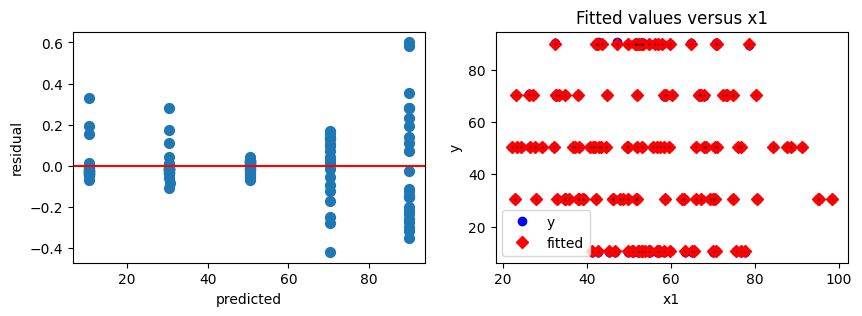

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
ax=axes[0]
ax.scatter(results.predict(), results.resid, s=50)
ax.axhline(0, color="red")
ax.set_xlabel("predicted")
ax.set_ylabel("residual")
sm.graphics.plot_fit(results,0,ax=axes[1]);

In [ ]:
design = np.column_stack((np.ones(len(df1)),one_hot[:,:-1]))
results = sm.OLS(df1["y"],design).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.283e+06
Date:                Wed, 06 May 2026   Prob (F-statistic):          3.48e-312
Time:                        12:37:54   Log-Likelihood:                 79.050
No. Observations:                 142   AIC:                            -148.1
Df Residuals:                     137   BIC:                            -133.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5292      0.027    394.635      0.0

#VIF
**Chat**, What's VIF — Variance Inflation Factor? how should I interpret it?

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
design = np.column_stack((df1["x"], np.ones(len(df1)),one_hot))
[VIF(design,i) for i in range(design.shape[1])]

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


[np.float64(1.0112578144303035),
 np.float64(0.0),
 np.float64(inf),
 np.float64(inf),
 np.float64(inf),
 np.float64(inf),
 np.float64(inf)]

**Chat**,
1. I got VIF = inf, what does it mean?
 - What should I do?

In [ ]:
design = np.column_stack((df1["x"], np.ones(len(df1)),one_hot[:,:-1]))
[VIF(design,i) for i in range(design.shape[1])]

[np.float64(1.0112578144303035),
 np.float64(17.044162525851814),
 np.float64(1.5478187833988721),
 np.float64(1.519066795564276),
 np.float64(1.723036112850093),
 np.float64(1.6669922755992486)]

Chat, the parameter of X is $\approx$ 0 but the VIF of the intercept is inflated. Explain why.

**Chat**, here's:
- the datasaurus hlines data plot,
- the design matrix,
- the VIFs I get.

Why is the second VIF so large? I didn't fall for the dummy variable trap BTW.

In [ ]:
design = np.column_stack((np.ones(len(df1)),one_hot[:,:-1]))
[VIF(design,i) for i in range(design.shape[1])]

[np.float64(5.071428571428572),
 np.float64(1.5432595573440642),
 np.float64(1.5090543259557336),
 np.float64(1.7062374245472836),
 np.float64(1.659959758551308)]

#Go furhter
**Chat**,
1. Help me engineer good features for regression for the Datasuarus dozen datasets. Let's start with circle.
2. What are GLMs? Compare with OLS. Explain what's a link function. Show me a simple example with statsmodels.
2. Compare the classical statistical approach to OLS against linear regression as a ML model.
3. What's cross validation?
4. In linear regression, how can I use CV to detect \ estimate to following: goodness of fit, parameter CIs, high influence points, multicollinearity.

https://scikit-learn.org/stable/modules/cross_validation.html?utm_source=chatgpt.com
https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html

